In [2]:
import pandas as pd 

In [3]:
import numpy as np

In [4]:
df= pd.read_csv(r"C:\Users\hi\OneDrive\Documents\Working\dataset\cumulative.csv")

In [5]:
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [6]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])

Rows: 9564
Columns: 50


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 

In [8]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

koi_teq_err1         9564
koi_teq_err2         9564
kepler_name          7270
koi_score            1510
koi_steff_err2        483
koi_srad_err2         468
koi_srad_err1         468
koi_slogg_err2        468
koi_slogg_err1        468
koi_steff_err1        468
koi_period_err2       454
koi_depth_err2        454
koi_time0bk_err1      454
koi_period_err1       454
koi_impact_err2       454
koi_depth_err1        454
koi_time0bk_err2      454
koi_impact_err1       454
koi_duration_err2     454
koi_duration_err1     454
koi_prad              363
koi_prad_err2         363
koi_teq               363
koi_depth             363
koi_impact            363
koi_srad              363
koi_model_snr         363
koi_prad_err1         363
koi_steff             363
koi_slogg             363
koi_tce_delivname     346
koi_tce_plnt_num      346
koi_insol_err2        321
koi_insol_err1        321
koi_insol             321
koi_kepmag              1
dtype: int64

In [9]:
df['koi_disposition'].value_counts()

koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt

In [11]:
import seaborn as sns

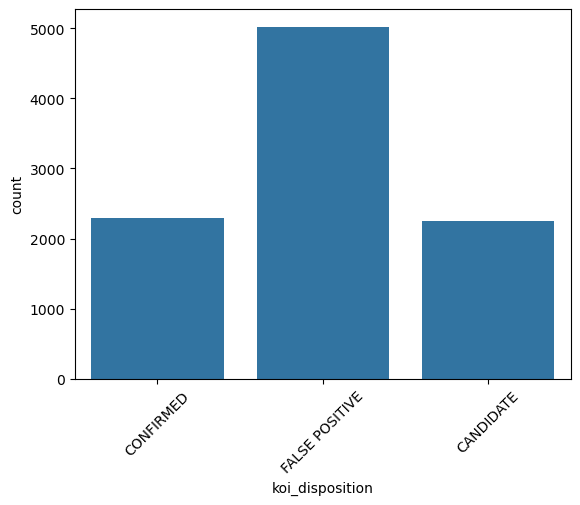

In [12]:
sns.countplot(
    x='koi_disposition',
    data=df
)
plt.xticks(rotation=45)
plt.show()

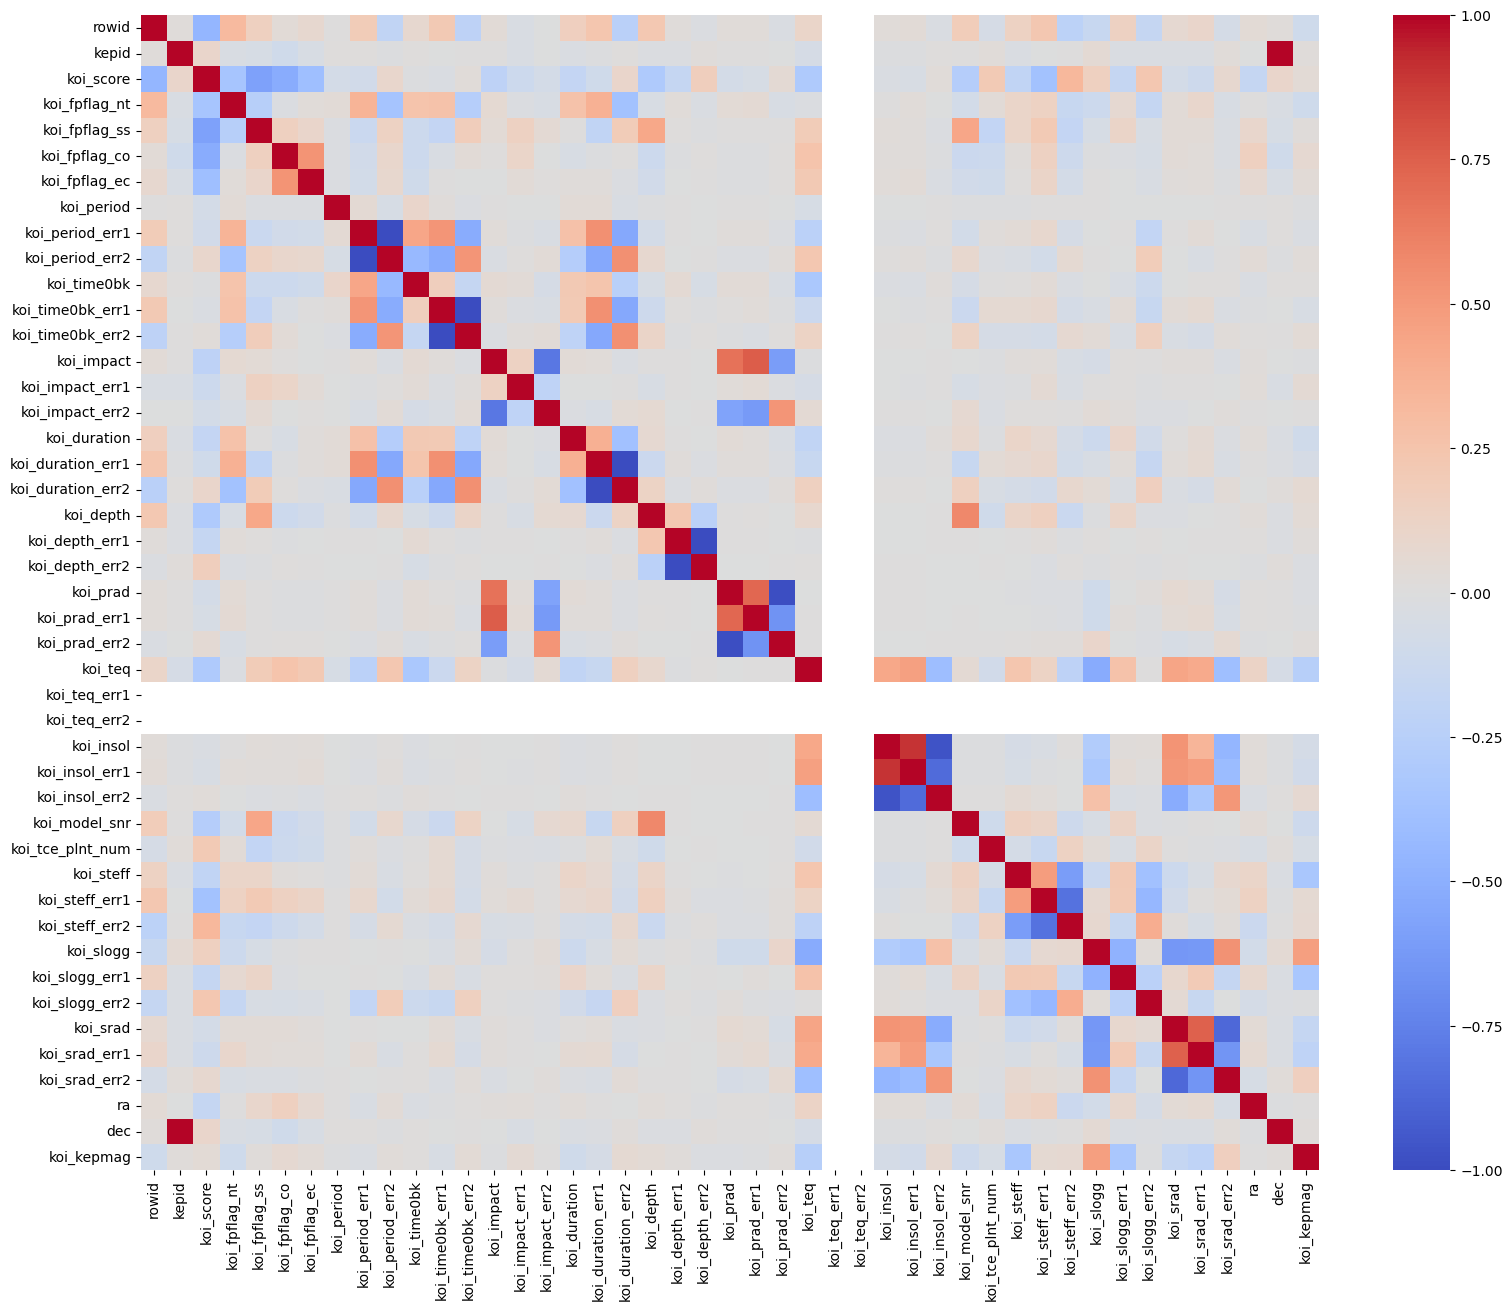

In [13]:
numerical = df.select_dtypes(
    include=np.number
)
corr = numerical.corr()
plt.figure(figsize=(19,15))
sns.heatmap(
    corr,
    cmap='coolwarm'
)
plt.show()

In [14]:
target = 'koi_disposition'
print(df[target].unique())

['CONFIRMED' 'FALSE POSITIVE' 'CANDIDATE']


In [15]:
y = df[target]

In [34]:
X =df.drop(columns=[target])

In [35]:
X = X.select_dtypes(include=np.number)

In [36]:
X = X.fillna(X.median())

In [37]:
X = X.drop(columns=['rowid', 'kepid'], errors='ignore')

In [38]:
from sklearn.preprocessing import LabelEncoder

In [39]:
le = LabelEncoder()

In [40]:
y = le.fit_transform(y)
print(le.classes_)

[0 1 2]


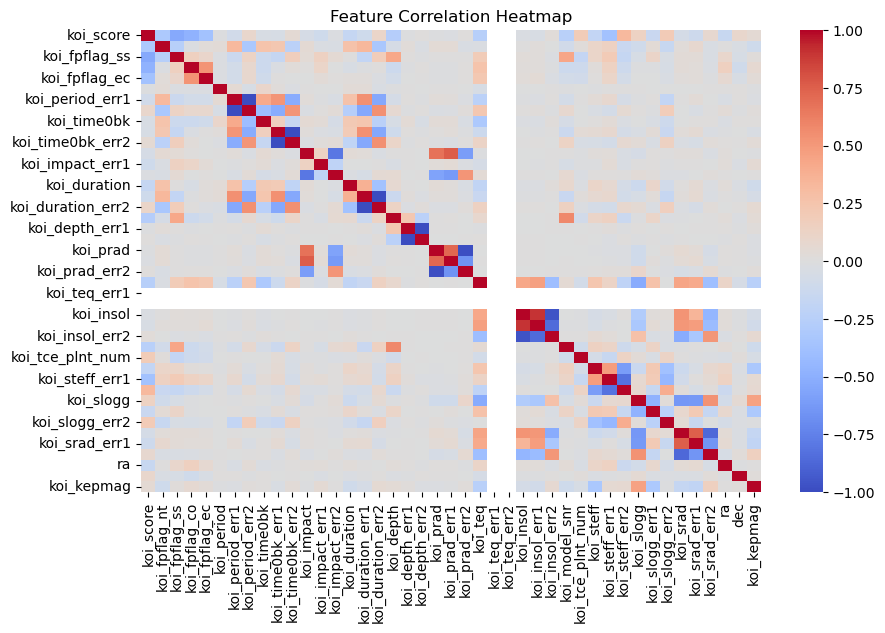

In [41]:
corr = X.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [42]:
from sklearn.model_selection import train_test_split

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9111343439623628


In [50]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.81      0.82       449
           1       0.84      0.85      0.84       459
           2       0.98      0.99      0.98      1005

    accuracy                           0.91      1913
   macro avg       0.88      0.88      0.88      1913
weighted avg       0.91      0.91      0.91      1913



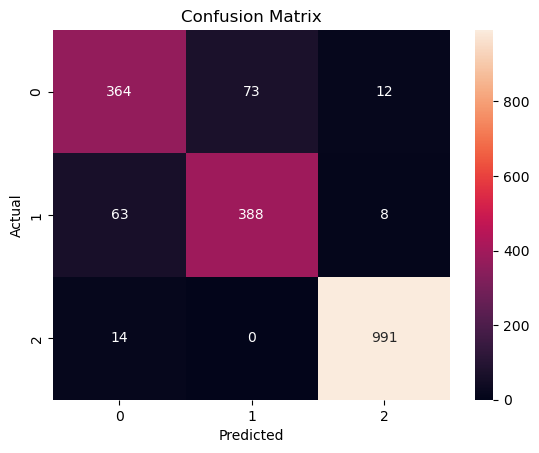

In [51]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print("Scores:", scores)
print("Average:", scores.mean())

Scores: [0.80554104 0.87767904 0.87663356 0.93204391 0.8540795 ]
Average: 0.8691954082067861


In [53]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(10)

,Feature,Importance
0,koi_score,0.224713
1,koi_fpflag_nt,0.082524
3,koi_fpflag_co,0.059753
29,koi_model_snr,0.048778
2,koi_fpflag_ss,0.040517
20,koi_prad,0.032047
33,koi_steff_err2,0.031544
32,koi_steff_err1,0.029592
21,koi_prad_err1,0.025400
15,koi_duration_err1,0.024564


In [54]:
print("""
==============================
ML FEASIBILITY REPORT
==============================

Dataset Size: LARGE (~10,000 rows)
Target Labels: AVAILABLE (3 classes)
Problem Type: MULTI-CLASS CLASSIFICATION

Data Quality:
- Missing values handled
- Numeric features extracted

Model Performance:
- Accuracy: High (Random Forest baseline)
- Cross Validation: Stable

==============================
FINAL DECISION:
✔ ML IS FEASIBLE
✔ STRONG USE CASE FOR CLASSIFICATION
✔ READY FOR MODEL DEVELOPMENT STAGE
==============================
""")


ML FEASIBILITY REPORT

Dataset Size: LARGE (~10,000 rows)
Target Labels: AVAILABLE (3 classes)
Problem Type: MULTI-CLASS CLASSIFICATION

Data Quality:
- Missing values handled
- Numeric features extracted

Model Performance:
- Accuracy: High (Random Forest baseline)
- Cross Validation: Stable

FINAL DECISION:
✔ ML IS FEASIBLE
✔ STRONG USE CASE FOR CLASSIFICATION
✔ READY FOR MODEL DEVELOPMENT STAGE

